In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity('WARNING')
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name='kang_15K_pbmc_rnaseq',
    save_path='scarf_datasets',
    as_zarr=True
)

scarf.fetch_dataset(
    dataset_name='kang_14K_ifnb-pbmc_rnaseq', 
    save_path='scarf_datasets',
    as_zarr=True
)

In [3]:
ds_ctrl = scarf.DataStore(
    'scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr/',
    nthreads=4
)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'cluster_labels', 
            'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_UMAP2', 'RNA_leiden_cluster', 
            'RNA_UMAP1'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'nCells', 
            'dropOuts'

In [4]:
ds_stim = scarf.DataStore(
    'scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr',
    nthreads=4
)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'cluster_labels', 
            'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_UMAP2', 
            'RNA_UMAP1'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

In [5]:
scarf.AssayMerge(
    zarr_path='scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=['ctrl', 'stim'],
    merge_assay_name='RNA',
    prepend_text='orig',
    reset_cell_filter=False,
    source_column='sample_id',
    overwrite=True,
).dump()

In [6]:
ds = scarf.DataStore(
    'scarf_datasets/kang_merged_pbmc_rnaseq.zarr',
    nthreads=4
)

Minimum cell count (562) is lower than size factor multiplier (1000)



In [7]:
ds

DataStore has 18598 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'orig_RNA_nCounts', 'orig_RNA_UMAP1', 
            'orig_RNA_percentMito', 'RNA_percentMito', 'orig_RNA_UMAP2', 'orig_cluster_labels', 'orig_RNA_percentRibo', 
            'RNA_nFeatures', 'orig_RNA_nFeatures', 'RNA_percentRibo', 'orig_RNA_leiden_cluster', 'RNA_nCounts', 
            'sample_id'
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'nCells', 
          

In [8]:
ds.cells.head()

,I,ids,names,orig_RNA_UMAP1,RNA_percentMito,orig_RNA_nCounts,orig_RNA_percentMito,orig_RNA_percentRibo,orig_RNA_UMAP2,RNA_percentRibo,orig_cluster_labels,orig_RNA_nFeatures,RNA_nFeatures,orig_RNA_leiden_cluster,RNA_nCounts,sample_id
0,False,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,NaN,0.000000,574.0,0.000000,20.034843,NaN,20.034843,nan,304.0,304.0,-1,574.0,ctrl
1,False,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,NaN,0.000000,1682.0,0.000000,0.059453,NaN,0.059453,nan,62.0,62.0,-1,1682.0,ctrl
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,-1.768571,0.171233,1168.0,0.171233,31.763699,-5.990341,31.763699,CD4 Memory T,434.0,434.0,1,1168.0,ctrl
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,-3.052445,0.185357,2158.0,0.185357,32.483781,-12.830768,32.483781,CD8 T,837.0,837.0,7,2158.0,ctrl
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,-12.654625,0.143369,1395.0,0.143369,34.695341,-5.425503,34.695341,B,592.0,592.0,5,1395.0,ctrl


In [9]:
ds.cells.to_pandas_dataframe(
    ['sample_id'],
    key='I'
)['sample_id'].value_counts()

sample_id
stim    10111
ctrl     8487
Name: count, dtype: int64

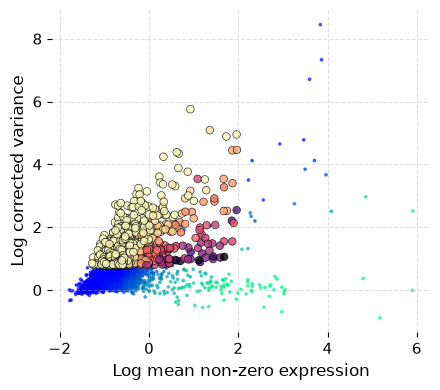

In [10]:
ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3, 
    max_mean=2,
    max_var=6
)

In [11]:
ds.make_graph(
    feat_key='hvgs',
    k=21, 
    dims=25,
    n_centroids=100
)

In [12]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True
)

In [13]:
ds.cells.head()

,I,ids,names,orig_RNA_nCounts,orig_RNA_UMAP1,orig_RNA_percentMito,RNA_percentMito,orig_RNA_UMAP2,orig_RNA_percentRibo,orig_cluster_labels,RNA_percentRibo,RNA_nCounts,RNA_nFeatures,orig_RNA_leiden_cluster,orig_RNA_nFeatures,RNA_UMAP2,RNA_UMAP1,sample_id
0,False,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,574.0,NaN,0.000000,0.000000,NaN,20.034843,nan,20.034843,574.0,304.0,-1,304.0,NaN,NaN,ctrl
1,False,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,1682.0,NaN,0.000000,0.000000,NaN,0.059453,nan,0.059453,1682.0,62.0,-1,62.0,NaN,NaN,ctrl
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,1168.0,-1.768571,0.171233,0.171233,-5.990341,31.763699,CD4 Memory T,31.763699,1168.0,434.0,1,434.0,12.482991,13.447552,ctrl
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,2158.0,-3.052445,0.185357,0.185357,-12.830768,32.483781,CD8 T,32.483781,2158.0,837.0,7,837.0,1.179820,19.053114,ctrl
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,1395.0,-12.654625,0.143369,0.143369,-5.425503,34.695341,B,34.695341,1395.0,592.0,5,592.0,22.765390,-23.168940,ctrl


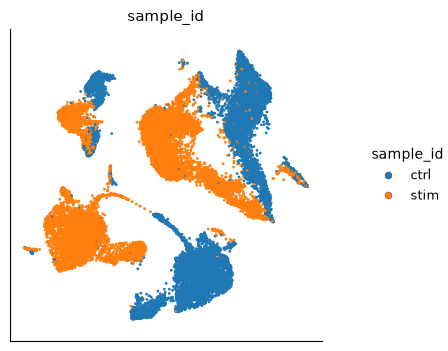

In [14]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='sample_id',
    legend_loc='right',
).show();

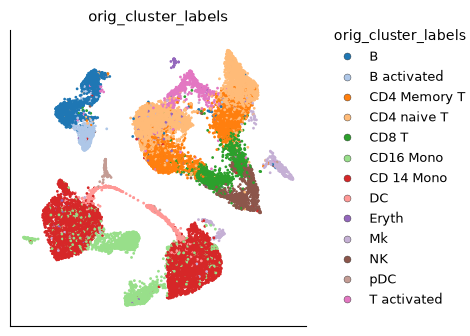

In [15]:
splt.embedding(
    ds,
    layout_key='RNA_UMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
).show();

In [16]:
ds.cells.insert(
    column_name=f'is_ctrl',
    values=(ds.cells.fetch_all('sample_id') == 'ctrl'),
    overwrite=True
)

In [17]:
ds.make_graph(
    feat_key='hvgs',
    k=21, 
    dims=25,
    n_centroids=100,
    pca_cell_key='is_ctrl'
)

In [18]:
ds.run_umap(
    n_epochs=250, 
    spread=5,
    min_dist=1,
    parallel=True,
    label='pUMAP'
)

/home/parashar/scarf/scarf/metadata.py:416: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


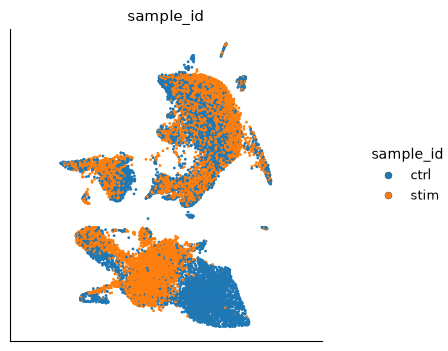

In [19]:
splt.embedding(
    ds,
    layout_key='RNA_pUMAP',
    color_by='sample_id',
    legend_loc='right',
).show();

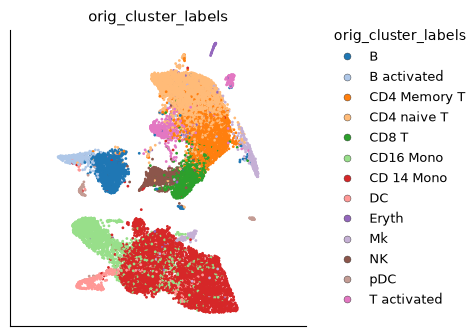

In [20]:
splt.embedding(
    ds,
    layout_key='RNA_pUMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
).show();

In [21]:
ds.make_graph(
    feat_key='hvgs',
    k=21,
    dims=25,
    n_centroids=100,
    harmonize=True,
    batch_columns=['sample_id'],
)

ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label='hUMAP'
)

ds.run_leiden_clustering(resolution=1.0)

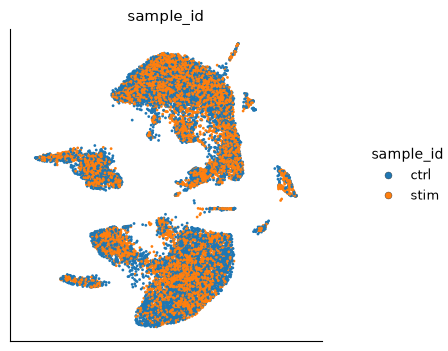

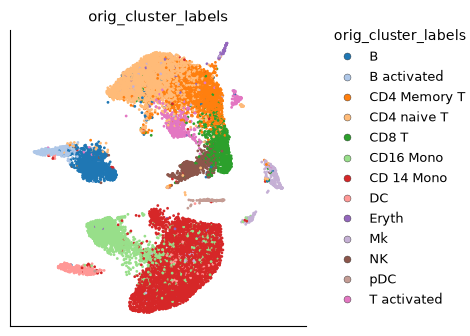

In [22]:
splt.embedding(
    ds,
    layout_key='RNA_hUMAP',
    color_by='sample_id',
    legend_loc='right',
).show();

splt.embedding(
    ds,
    layout_key='RNA_hUMAP',
    color_by='orig_cluster_labels',
    legend_loc='right',
).show();

In [23]:
ds.metric_lisi(
    label_colnames=['sample_id', 'orig_cluster_labels'],
    save_result=True,
)

Perplexity 30 requires at least 90 neighbors, but the graph has 21. Using perplexity 7.



[('sample_id',
  array([1.23625916, 1.17942804, 1.33316355, ..., 1.84760332, 1.98844049,
         1.61671253], shape=(18598,))),
 ('orig_cluster_labels',
  array([1.        , 1.04153798, 1.49017686, ..., 1.        , 1.13581301,
         1.        ], shape=(18598,)))]

In [24]:
ds.metric_batch_mixing(label_colname='sample_id')

Perplexity 30 requires at least 90 neighbors, but the graph has 21. Using perplexity 7.



0.3418633960433675

In [25]:
ds.metric_silhouette(res_label='leiden_cluster')

array([ 0.02488094,  0.08685683,  0.18735732,  0.10992459,  0.20124428,
        0.36118883,  0.23056164,  0.07935803,  0.12434942, -0.00893679,
        0.23190273,  0.27458349,  0.17185568,  0.36251517, -0.04664297,
        0.42001305,  0.19039756])

In [26]:
ds.metric_label_concordance(
    label_columns=['RNA_leiden_cluster', 'orig_cluster_labels'],
    metric='ari'
)

0.8546022504136203